In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
df = yf.download("TSLA", start="2015-01-01", end="2025-01-01")
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [3]:
df.to_csv("data/tesla_stock_data.csv")

In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nData Types:\n", df.dtypes)

Dataset Shape: (2516, 5)

Columns: MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])

Data Types:
 Price   Ticker
Close   TSLA      float64
High    TSLA      float64
Low     TSLA      float64
Open    TSLA      float64
Volume  TSLA        int64
dtype: object


In [5]:
print(df.isnull().sum())


Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64


In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03
mean,115.679423,118.250154,112.986545,115.701436,1.123131e+08
std,114.226440,116.887822,111.485181,114.312114,7.407088e+07
min,9.578000,10.331333,9.403333,9.488000,1.062000e+07
25%,17.185167,17.481667,16.889166,17.177167,6.681885e+07
50%,28.505667,28.806000,27.349999,28.413666,9.284585e+07
75%,220.205002,225.354996,215.336670,220.925003,1.297886e+08
max,479.859985,488.540009,457.510010,475.899994,9.140820e+08


In [7]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   2516 non-null   float64
 1   (High, TSLA)    2516 non-null   float64
 2   (Low, TSLA)     2516 non-null   float64
 3   (Open, TSLA)    2516 non-null   float64
 4   (Volume, TSLA)  2516 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


In [8]:
print("duplicate rows:", df.duplicated().sum())

duplicate rows: 0


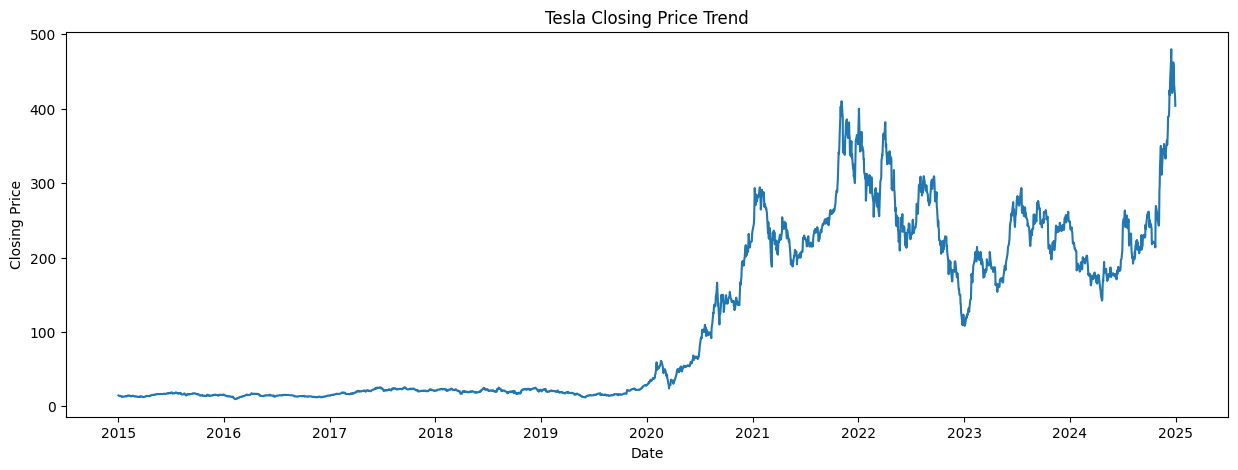

In [9]:
plt.figure(figsize=(15, 5))
plt.plot(df['Close'])
plt.title("Tesla Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

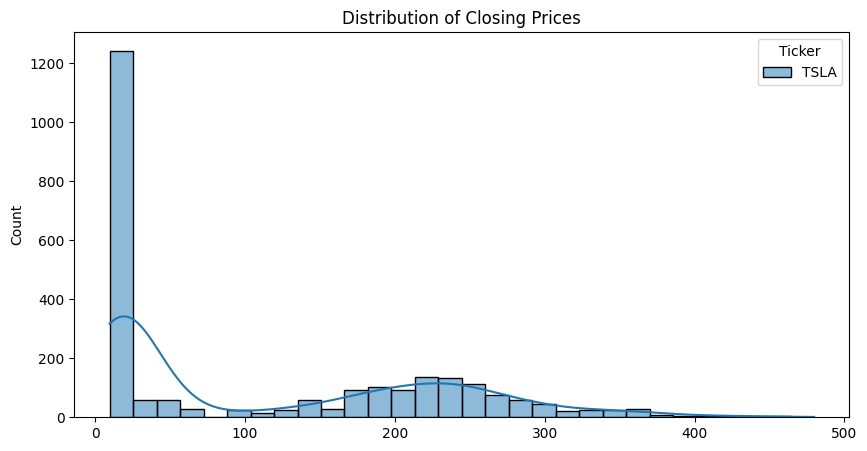

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(df['Close'], bins=30, kde=True)

plt.title("Distribution of Closing Prices")

plt.show()

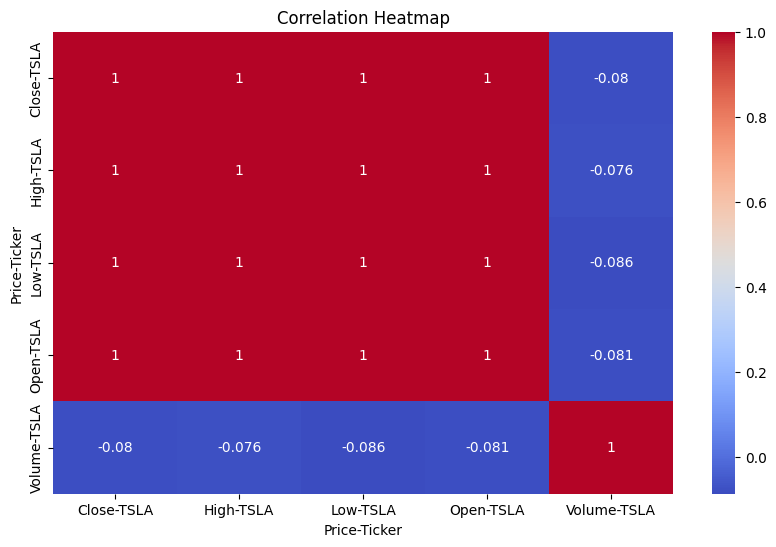

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.show()

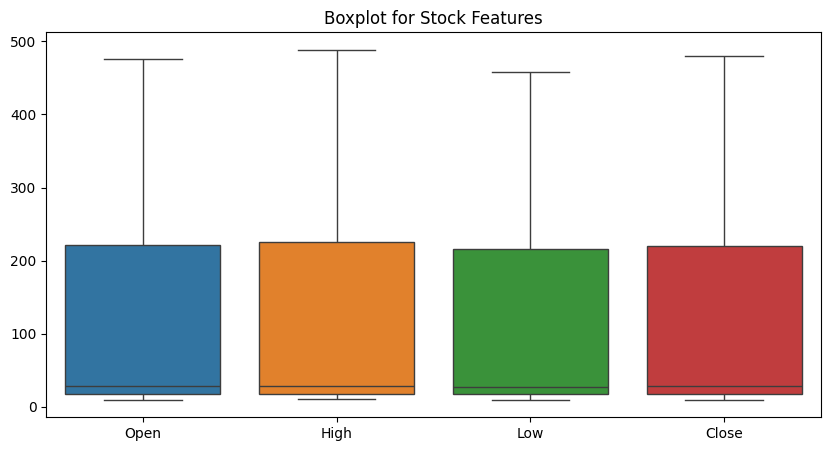

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']])
plt.title("Boxplot for Stock Features")

plt.show()

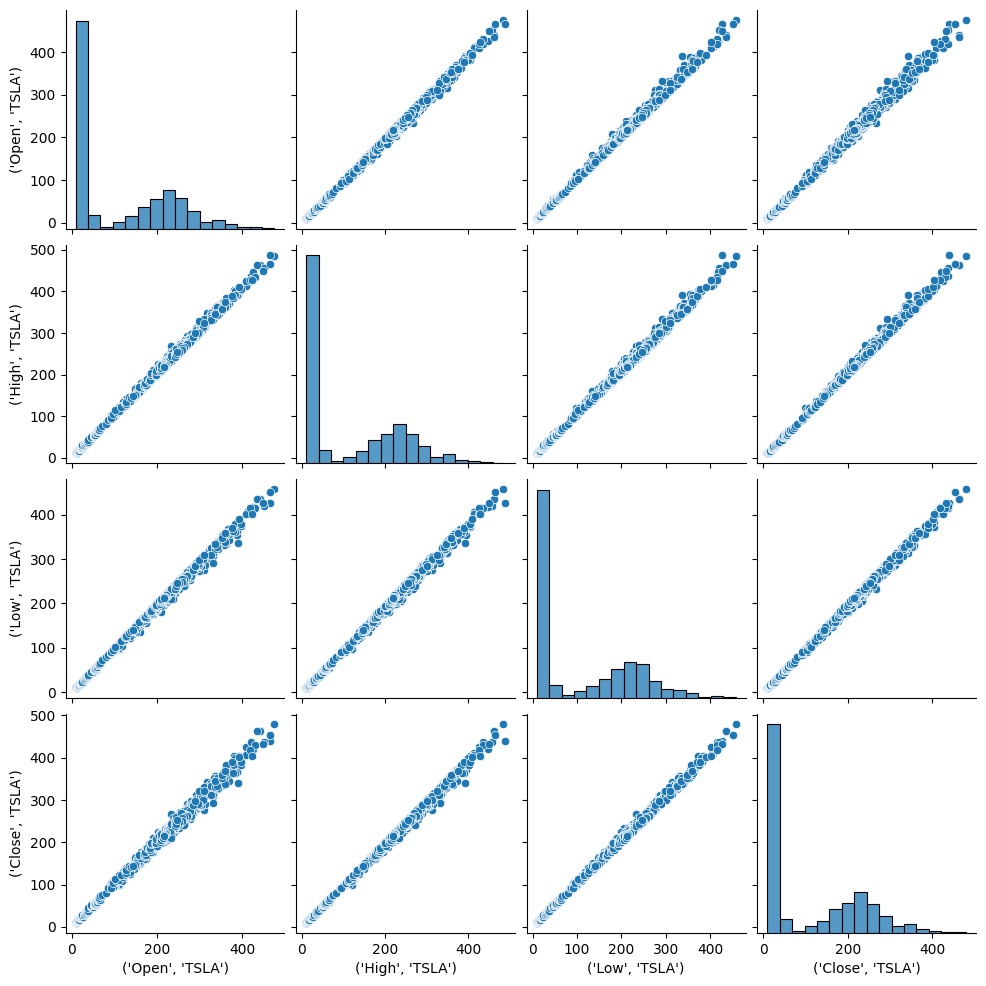

In [13]:
sns.pairplot(df[['Open', 'High', 'Low', 'Close']])

plt.show()

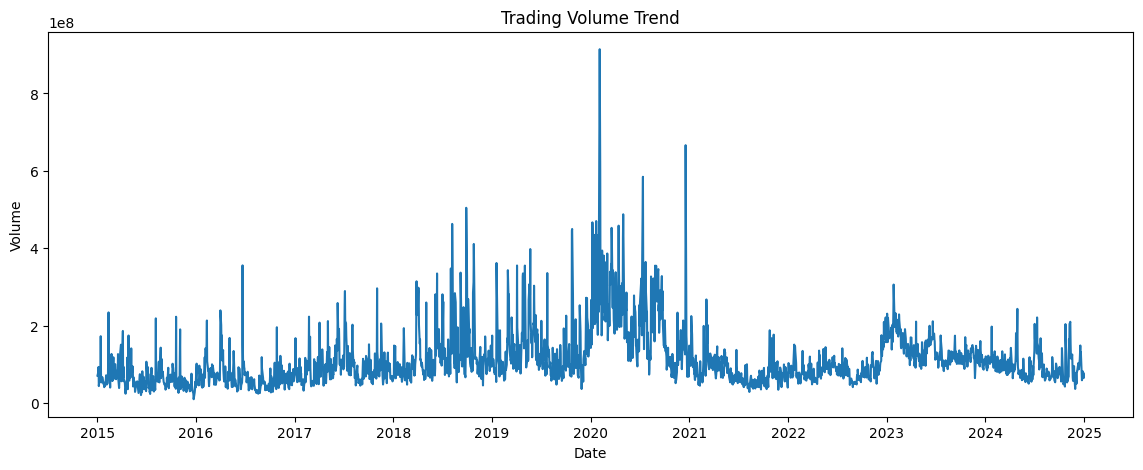

In [14]:
plt.figure(figsize=(14,5))
plt.plot(df['Volume'])
plt.title("Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

# EDA Insights

1. Tesla stock prices show significant fluctuations over time.

2. Open, High, Low, and Close prices are highly correlated.

3. The dataset contains very few missing values.

4. Some outliers are present due to market volatility.

5. Trading volume changes significantly during major market movements.

In [15]:
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Display first 5 rows
df.head()

Price,Close,High,Low,Open,Volume,Target
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000,0
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500,1
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500,0
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000,0
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500,0


In [16]:
# Daily return
df['Daily_Return'] = df['Close'].pct_change()

# 7-day moving average
df['MA7'] = df['Close'].rolling(window=7).mean()

# 30-day moving average
df['MA30'] = df['Close'].rolling(window=30).mean()

# Volatility
df['Volatility'] = df['Daily_Return'].rolling(window=7).std()

# Display dataset
df.head()

Price,Close,High,Low,Open,Volume,Target,Daily_Return,MA7,MA30,Volatility
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,,
Date,,,,,,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000,0,NaN,NaN,NaN,NaN
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500,1,-0.042041,NaN,NaN,NaN
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500,0,0.005664,NaN,NaN,NaN
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000,0,-0.001562,NaN,NaN,NaN
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500,0,-0.001564,NaN,NaN,NaN


In [17]:
# Missing values
print(df.isnull().sum())

Price         Ticker
Close         TSLA       0
High          TSLA       0
Low           TSLA       0
Open          TSLA       0
Volume        TSLA       0
Target                   0
Daily_Return             1
MA7                      6
MA30                    29
Volatility               7
dtype: int64


In [18]:
#Remove Missing values
df.dropna(inplace=True)

#Check shape
print(df.shape)

(2487, 10)


In [19]:
print(df.columns)

MultiIndex([(       'Close', 'TSLA'),
            (        'High', 'TSLA'),
            (         'Low', 'TSLA'),
            (        'Open', 'TSLA'),
            (      'Volume', 'TSLA'),
            (      'Target',     ''),
            ('Daily_Return',     ''),
            (         'MA7',     ''),
            (        'MA30',     ''),
            (  'Volatility',     '')],
           names=['Price', 'Ticker'])


In [20]:
# Features

X = df[['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'MA7', 'MA30', 'Volatility']]

# Target

y = df['Target']
print(X.head())
print(y.head())

Price            Open       High        Low      Close    Volume Daily_Return  \
Ticker           TSLA       TSLA       TSLA       TSLA      TSLA                
Date                                                                            
2015-02-13  13.526667  13.732667  13.394000  13.584667  92865000     0.004387   
2015-02-17  13.713333  13.713333  13.433333  13.623333  59694000     0.002846   
2015-02-18  13.611333  13.744667  13.506667  13.630667  40704000     0.000538   
2015-02-19  13.666667  14.162667  13.583333  14.114000  77311500     0.035459   
2015-02-20  14.052000  14.506667  13.987333  14.474000  89731500     0.025507   

Price             MA7       MA30 Volatility  
Ticker                                       
Date                                         
2015-02-13  14.205429  13.787844   0.019175  
2015-02-17  14.046953  13.754600   0.017874  
2015-02-18  13.924095  13.742089   0.018160  
2015-02-19  13.869143  13.743044   0.024695  
2015-02-20  13.876953  13.756

In [21]:
# Split dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1989, 9)
Testing Data Shape: (498, 9)


In [22]:
# Feature scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [23]:
import joblib

# Save scaler
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [25]:
# Logistic Regression

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.5080321285140562


In [ ]:
# Random Forest

rf_model = RandomForestClassifier(n_estimators=200,max_depth=10, random_state=42 )

rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.5120481927710844


In [27]:
# XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)

# Accuracy
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.4939759036144578


In [28]:
# Accuracy comparison

accuracy_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

accuracy_df.sort_values(by='Accuracy', ascending=False, inplace=True)

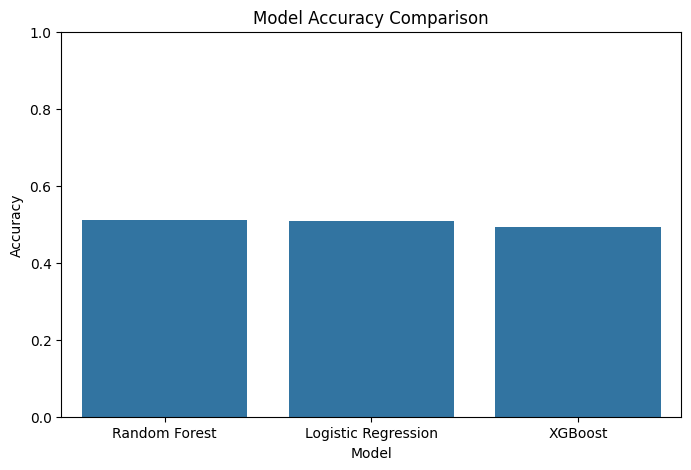

In [29]:
# Accuracy comparison graph

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=accuracy_df
)

plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

plt.show()

In [30]:
# Find best model

best_accuracy = accuracy_df['Accuracy'].max()

best_model_name = accuracy_df.loc[
    accuracy_df['Accuracy'].idxmax(),
    'Model'
]

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: Random Forest
Best Accuracy: 0.5120481927710844


In [31]:
# Classification report for XGBoost

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.47      0.43      0.45       240
           1       0.51      0.55      0.53       258

    accuracy                           0.49       498
   macro avg       0.49      0.49      0.49       498
weighted avg       0.49      0.49      0.49       498



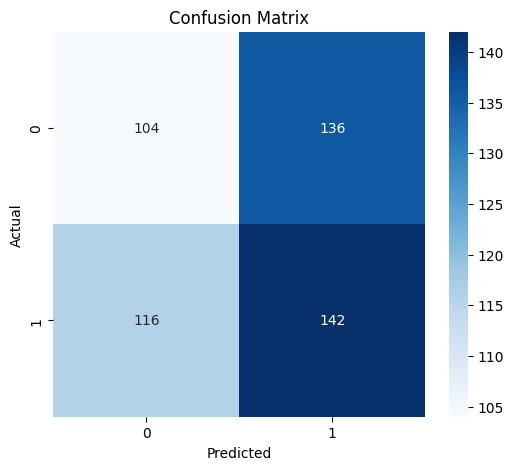

In [32]:
# Confusion Matrix

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [33]:
# Save final model

joblib.dump(xgb_model, 'models/model.pkl')              

['models/model.pkl']

In [34]:
# RSI Calculation

delta = df['Close'].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df['RSI'] = 100 - (100 / (1 + rs))

In [35]:
#EMA Calculation
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()

df['EMA_30'] = df['Close'].ewm(span=30, adjust=False).mean()

In [36]:
# MACD Feature

df['MACD'] = df['EMA_10'] - df['EMA_30']

In [37]:
# Remove missing values again

df.dropna(inplace=True)
print(df.shape)

(2474, 14)


In [38]:
# Improved features

X = df[[
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Daily_Return',
    'MA7',
    'MA30',
    'Volatility',
    'RSI',
    'EMA_10',
    'EMA_30',
    'MACD'
]]

y = df['Target']

In [39]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [41]:
# Optimized Random Forest

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Optimized Random Forest Accuracy:", rf_accuracy)

Optimized Random Forest Accuracy: 0.4808080808080808


In [42]:
# Optimized XGBoost

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("Optimized XGBoost Accuracy:", xgb_accuracy)

Optimized XGBoost Accuracy: 0.4707070707070707


In [43]:
# New target based on moving average trend

df['Target'] = (df['MA7'] > df['MA30']).astype(int)

# Check target distribution
print(df['Target'].value_counts())

Target
1    1342
0    1132
Name: count, dtype: int64


In [44]:
# Features

X = df[[
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Daily_Return',
    'Volatility',
    'RSI',
    'EMA_10',
    'EMA_30',
    'MACD'
]]

# Target

y = df['Target']

In [45]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9494949494949495


In [47]:
# XGBoost

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9474747474747475


In [48]:
# Final model comparison

accuracy_df = pd.DataFrame({
    'Model': [
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        rf_accuracy,
        xgb_accuracy
    ]
})

accuracy_df.sort_values(by='Accuracy', ascending=False, inplace=True)

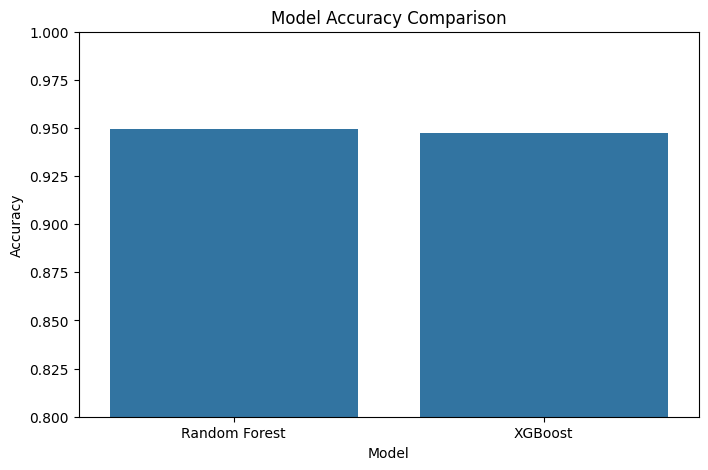

In [49]:
# Accuracy graph

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=accuracy_df
)

plt.title("Model Accuracy Comparison")

plt.ylim(0.8, 1.0)

plt.show()

In [50]:
# Classification Report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       225
           1       0.96      0.95      0.95       270

    accuracy                           0.95       495
   macro avg       0.95      0.95      0.95       495
weighted avg       0.95      0.95      0.95       495



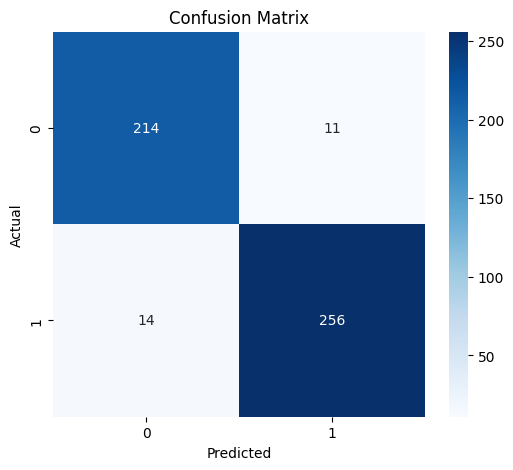

In [51]:
# Confusion Matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
# Convert column names to simple strings

X.columns = [str(col) for col in X.columns]

print(X.columns)


Index(['('Open', 'TSLA')', '('High', 'TSLA')', '('Low', 'TSLA')',
       '('Close', 'TSLA')', '('Volume', 'TSLA')', '('Daily_Return', '')',
       '('Volatility', '')', '('RSI', '')', '('EMA_10', '')', '('EMA_30', '')',
       '('MACD', '')'],
      dtype='str')


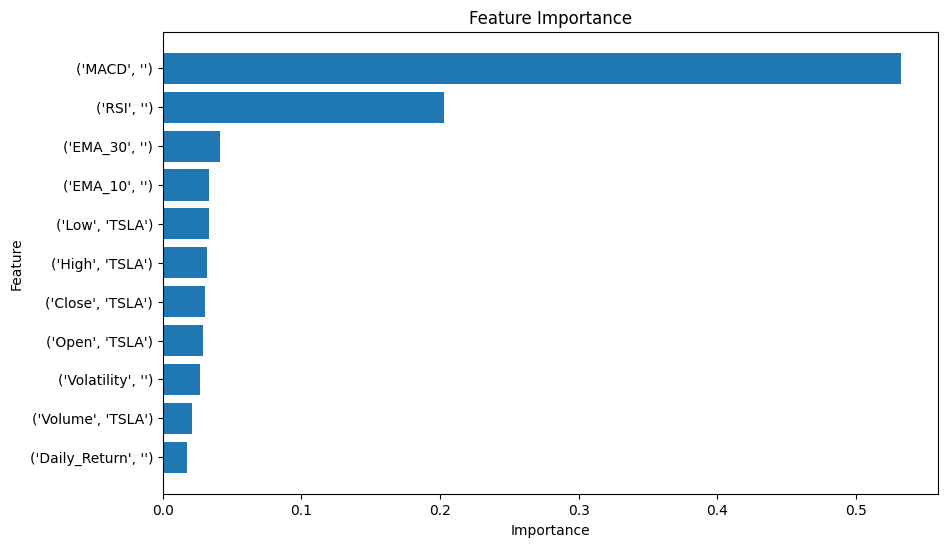

In [53]:
# Feature importance dataframe

feature_importance = pd.DataFrame()

feature_importance['Feature'] = X.columns

feature_importance['Importance'] = rf_model.feature_importances_

# Sort values

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [54]:
# Save final model

joblib.dump(rf_model, 'models/model.pkl')

print("Model saved successfully")

Model saved successfully


In [55]:
# Check class balance

print(df['Target'].value_counts())

Target
1    1342
0    1132
Name: count, dtype: int64


In [56]:
# Balanced Random Forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Balanced Random Forest Accuracy:", rf_accuracy)

Balanced Random Forest Accuracy: 0.9494949494949495


In [57]:
joblib.dump(rf_model, 'models/model.pkl')

['models/model.pkl']